<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/8.%20Agentic%20AI%20Systems/14.%20DSPy%3A%20Mathematical%20Prompt%20Optimization/L14_DSPy_Mathematical_Prompt_Optimization.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# DSPy: Mathematical Prompt Optimization

### From Prompt Whisperer to Prompt Engineer

**Duration:** 120 minutes  
**Level:** Intermediate  
**Backend:** Groq API with `llama-3.1-8b-instant`  
**Dataset:** Financial PhraseBank from Hugging Face

## Overview

Building reliable LLM applications often requires more than writing a good prompt.

A prompt that performs well on a small set of examples may fail on new inputs. Manually modifying the prompt can also introduce new errors or make the system harder to maintain.

**DSPy** approaches this problem differently.

Instead of manually rewriting prompts, DSPy allows you to define what an LLM program should do and then **optimize the program algorithmically** using data and evaluation metrics.

The process can be summarized as:

```text
Task Definition
      ↓
DSPy Program
      ↓
Evaluation
      ↓
Optimization
      ↓
Improved Program

## Section 0: Environment Setup (~5 min)

### Get your free Groq API key

1. Go to https://console.groq.com/keys
2. Sign in (Google/GitHub works)
3. Create an API key, copy it
4. Paste it when prompted below

Groq's free tier gives us around 30 requests/min for `llama-3.1-8b-instant`, which is plenty for this class if we batch carefully.


In [ ]:
# Install everything we need. This takes ~60 seconds in Colab.
# NOTE: the package is now `dspy` (the old `dspy-ai` name is deprecated). We intentionally
# leave versions unpinned so pip resolves builds compatible with your Python (incl. 3.12+/3.14).
# The notebook uses the modern dspy API (dspy.LM, teleprompters, MIPROv2), which needs dspy>=2.5.
!pip install -q -U "dspy>=2.5" datasets langchain-core groq matplotlib
import dspy
print("Install complete. dspy version:", dspy.__version__)

Install complete. dspy version: 3.2.1


In [ ]:
# Import everything upfront so failures show up early
import os
import random
import time
import getpass
from collections import Counter

import dspy
from datasets import load_dataset
import matplotlib.pyplot as plt

# Reproducibility
random.seed(42)

print("DSPy version:", dspy.__version__)

DSPy version: 3.2.1


In [ ]:
# Groq API key handling. Two paths:
#   (a) Colab: store as a secret named GROQ_API_KEY, we'll auto-pick it up
#   (b) Otherwise: paste when prompted

api_key = None
try:
    from google.colab import userdata
    api_key = userdata.get('GROQ_API_KEY')
    print("Loaded key from Colab secrets.")
except Exception:
    pass

if not api_key:
    api_key = getpass.getpass("Paste your Groq API key: ").strip()

os.environ["GROQ_API_KEY"] = api_key
assert api_key.startswith("gsk_"), "Groq keys start with 'gsk_'. Please recheck."
print("API key registered.")

Loaded key from Colab secrets.
API key registered.


In [ ]:
# Configure DSPy to talk to Groq.
# DSPy uses LiteLLM under the hood, so we route via the "groq/" prefix.

lm = dspy.LM(
    model="groq/llama-3.1-8b-instant",
    api_key=os.environ["GROQ_API_KEY"],
    max_tokens=512,
    temperature=0.0,   # deterministic-ish for classification
)
dspy.configure(lm=lm)

# Sanity check: one round-trip
resp = lm("Reply with exactly the word: pong")
print("Sanity check response:", resp)

Sanity check response: ['pong']


## Section 1: The Prompt Engineering Crisis (~10 min)

### The 3 AM prompt debugging story

You wrote this prompt on Monday:

> *"You are a helpful financial analyst. Classify the sentiment of the following headline as positive, negative, or neutral. Headline: {text}"*

Accuracy: **58%**. Fine, you'll iterate.

**Tuesday:** You add "Think step by step." Accuracy: **63%**. Progress.

**Wednesday:** You add 3 examples. Accuracy: **71%**. But now it hallucinates a 4th category ("mixed") on 8% of inputs.

**Thursday 3 AM:** You add "Only respond with one of the exact words: positive, negative, neutral." Accuracy: **68%**. It got *worse*. Why?

**Friday:** Your CTO swaps the model from Llama-3.1-8b to Llama-3.1-70b for cost reasons. All your careful tuning evaporates. Accuracy: **54%**.

### Why does this happen?

Manual prompt engineering has four structural problems:

| Problem | What it feels like |
|---|---|
| **Non-compositional** | Fixing one failure mode breaks two others |
| **Non-portable** | Rewrites needed when you swap models |
| **Non-measurable** | You "feel" it's better; you don't know |
| **Non-reproducible** | Your teammate can't reproduce your prompt magic |

### The core insight

> Prompts are **code**. Writing them by hand is like writing assembly. What we need is a **compiler**.

That compiler is DSPy.


### Analogy: Assembly vs. High-Level Languages

The evolution of software development provides a useful way to understand the problem DSPy is trying to solve.

### The Assembly Era

In the early days of computing, programmers often wrote software directly in assembly language.

This created several challenges:

- Programs were closely tied to specific CPU architectures.
- Different processors required different assembly instructions.
- Portability was difficult.
- Optimization required manually rewriting low-level instructions.

The programmer had to manage many implementation details directly.

### The Compiler Era

High-level programming languages changed this model.

Instead of writing CPU instructions manually, developers could describe what the program should do using languages such as C or Python.

The compiler then handled the translation:

```text
High-Level Program
       ↓
     Compiler
       ↓
Machine Code
       ↓
      CPU

### Where DSPy fits in the agentic AI stack

```
┌─────────────────────────────────────────────────┐
│  Agentic Framework (LangGraph, CrewAI, AutoGen) │  <- Orchestration
├─────────────────────────────────────────────────┤
│  Prompt Optimization (DSPy)                     │  <- What we learn today
├─────────────────────────────────────────────────┤
│  LLM Inference (Groq, OpenAI, Anthropic, ...)   │  <- Raw model calls
└─────────────────────────────────────────────────┘
```

DSPy sits between your agent framework and the raw model. It converts your **declarations** into **model-specific prompts** that are algorithmically tuned on your data.


### Quiz 1: Prompt Engineering Pitfalls

**Question:** Your team hand-tuned a prompt for GPT-4 and achieved 82% accuracy. Management asks you to switch to Claude 3.5 Sonnet to reduce costs.

You use the same prompt with the new model, but accuracy drops to 61%.

What is the **most fundamental** reason this happened?

**A.** Claude is a worse model than GPT-4

**B.** Prompts are model-specific artifacts; hand-tuning creates hidden dependencies on the tokenizer, formatting, and instruction-following behavior of a specific model

**C.** You need to add `"You are a helpful assistant"` for Claude to work

**D.** Claude has a smaller context window

### Correct Answer: B

Prompts are not necessarily portable across different LLMs.

Each model can have its own behavior and preferences, including how it:

- Interprets instructions
- Handles lists and structured formats
- Processes negation
- Responds to reasoning instructions
- Follows output-format constraints
- Interprets few-shot examples

When a prompt is manually tuned against a particular model, the prompt can become implicitly optimized for that model's behavior.

For example:

```text
Hand-tuned Prompt
       ↓
     GPT-4
       ↓
     82%

## Section 2: What is DSPy?

DSPy stands for **Declarative Self-improving Python**. It came out of Stanford NLP (Omar Khattab et al.) and is now the de-facto framework for **programming language models instead of prompting them**.

### The three pillars

#### 1. Signatures
A **typed declaration** of an LLM task. Not a prompt, a *specification*.

```python
class Classify(dspy.Signature):
    "Classify sentiment of financial news."
    headline: str = dspy.InputField()
    sentiment: str = dspy.OutputField(desc="one of: positive, negative, neutral")
```

Think of it as a **function type hint** for an LLM call.

#### 2. Modules
A **strategy** for executing a signature. Same signature, different modules, different behaviors.

- `dspy.Predict(Classify)`: single-shot classification
- `dspy.ChainOfThought(Classify)`: forces reasoning before answer
- `dspy.ReAct(Classify, tools=[...])`: tool-using agent
- `dspy.ProgramOfThought(Classify)`: generates Python code as reasoning

Think of it as **choosing an implementation strategy** for the declared function.

#### 3. Teleprompters (Optimizers)
The **compiler**. Given a module, a metric, and training data, it produces an *optimized* version of the module.

- `BootstrapFewShot`: learns which examples to include in the prompt
- `BootstrapFewShotWithRandomSearch`: searches over example combinations
- `MIPROv2`: jointly optimizes instructions AND examples using Bayesian-style search
- `BootstrapFinetune`: turns your prompt program into a fine-tuning job

Think of it as **the compiler** that turns your declaration + strategy into an actual working prompt.


### The mental model shift

| Old world (Prompting) | New world (DSPy) |
|---|---|
| Write a string | Declare a Signature |
| Copy-paste examples into the string | Provide training data separately |
| Guess at wording | Pick a Module strategy |
| Eyeball outputs | Define a Metric |
| Re-write on model swap | Recompile |

### Analogy: DSPy is to prompts what PyTorch is to neural nets

Before PyTorch, people wrote raw NumPy for backprop. It worked, but nobody could scale it or share it.

PyTorch gave us:
- `nn.Module` for **declaration**
- `optim.SGD` for **optimization**
- Autograd for **automatic differentiation**

DSPy gives us:
- `dspy.Signature` for **declaration**
- `dspy.Teleprompter` for **optimization**
- Bootstrapped demonstrations for **automatic prompt search**

Same abstraction shift, different domain.


### Quiz 2: Signatures vs. Modules

**Question:** You want an LLM to classify legal contracts by risk level, but you also want to see its reasoning before the final label so the result can be audited.

Which combination is correct?

**A.** Write one Signature with a longer prompt string

**B.** Write two separate Signatures, one for reasoning and one for classification

**C.** Write one Signature (`contract → risk_level`) and wrap it in `dspy.ChainOfThought`

**D.** Write one Signature (`contract → risk_level`) and wrap it in `dspy.Predict`, then post-process the output

### Correct Answer: C

The key distinction is between a **Signature** and a **Module**.

A **Signature** defines **what** the LLM should do.

For example:

```text
contract → risk_level

## Section 3: Loading the Battlefield: Financial PhraseBank

We'll use the **Financial PhraseBank** dataset (Malo et al., 2014), specifically the `sentences_75agree` split where at least 75% of human annotators agreed on the label. This gives us ~3400 high-quality labeled headlines.

Labels: `positive`, `negative`, `neutral`.

### Why financial sentiment is genuinely hard

Consider these three headlines:

1. *"Fed signals patience on rate cuts"*
   - Sounds **neutral**. But for growth stocks: **negative** (higher rates for longer).

2. *"Company X beats Q3 earnings by $0.02"*
   - Sounds **positive**. But if analysts expected $0.10 beat: market reads as **negative**.

3. *"Regulator opens preliminary inquiry into X"*
   - Sounds **negative**. But often priced in as **neutral** (inquiries rarely lead to action).

Generic sentiment classifiers get roasted here because they miss **domain semantics**. This is exactly the gap DSPy is going to close for us, without us hand-writing any of these rules.


In [ ]:
# Load Financial PhraseBank
# Note: this dataset requires `trust_remote_code=True` on some versions
raw = load_dataset("lmassaron/FinancialPhraseBank", trust_remote_code=True)
print(raw)
print("First 3 examples:")
for i in range(3):
    print(raw['train'][i])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lmassaron/FinancialPhraseBank' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lmassaron/FinancialPhraseBank' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


DatasetDict({
    train: Dataset({
        features: ['sentiment', 'sentence', 'label'],
        num_rows: 3872
    })
    validation: Dataset({
        features: ['sentiment', 'sentence', 'label'],
        num_rows: 484
    })
    test: Dataset({
        features: ['sentiment', 'sentence', 'label'],
        num_rows: 484
    })
})
First 3 examples:
{'sentiment': 'neutral', 'sentence': 'The shares carry a right to dividend and other shareholder rights as from their registration with the Finnish Trade Register .', 'label': 1}
{'sentiment': 'positive', 'sentence': 'UPM-Kymmene has generated four consecutive quarters of positive Free Cash Flow .', 'label': 2}
{'sentiment': 'positive', 'sentence': 'Known as Post Bank , the concept would see Fidelity Bank rolling out 75 offices in Ghana Post premises , to provide financial services to the people .', 'label': 2}


In [ ]:
# Map integer labels to strings
label_map = {0: "negative", 1: "neutral", 2: "positive"}

all_examples = []
for row in raw['train']:
    all_examples.append({
        "headline": row['sentence'],
        "sentiment": label_map[row['label']]
    })

print(f"Total examples: {len(all_examples)}")
print("Class distribution:", Counter(ex['sentiment'] for ex in all_examples))


Total examples: 3872
Class distribution: Counter({'neutral': 2298, 'positive': 1091, 'negative': 483})


In [ ]:
# Stratified sampling: we want balanced train/val/test to avoid the model
# just learning "predict neutral, get 60%"

def stratified_sample(examples, per_class):
    by_class = {"positive": [], "negative": [], "neutral": []}
    for ex in examples:
        by_class[ex['sentiment']].append(ex)
    for k in by_class:
        random.shuffle(by_class[k])
    sampled = []
    for k in by_class:
        sampled.extend(by_class[k][:per_class])
    random.shuffle(sampled)
    return sampled, {k: by_class[k][per_class:] for k in by_class}

# Shuffle the master pool first
random.shuffle(all_examples)

# Split: 20 train (for teleprompter), 50 val (for optimizer scoring), 100 test (final eval)
# We take a "per class" count so we're balanced.
train_raw, remaining = stratified_sample(all_examples, per_class=7)   # 21 total (7*3)
# Reflatten remaining pool
remaining_flat = sum(remaining.values(), [])
random.shuffle(remaining_flat)

val_raw, _ = stratified_sample(remaining_flat, per_class=17)  # 51 total
# Reflatten leftover
leftover = [ex for ex in remaining_flat if ex not in val_raw]

test_raw, _ = stratified_sample(leftover, per_class=34)  # 102 total

print(f"Train: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}")
print("Train distribution:", Counter(e['sentiment'] for e in train_raw))
print("Val distribution:  ", Counter(e['sentiment'] for e in val_raw))
print("Test distribution: ", Counter(e['sentiment'] for e in test_raw))


Train: 21 | Val: 51 | Test: 102
Train distribution: Counter({'negative': 7, 'neutral': 7, 'positive': 7})
Val distribution:   Counter({'negative': 17, 'neutral': 17, 'positive': 17})
Test distribution:  Counter({'neutral': 34, 'positive': 34, 'negative': 34})


In [ ]:
# Convert to DSPy Examples. This is the format teleprompters expect.
def to_dspy(examples):
    return [
        dspy.Example(headline=e['headline'], sentiment=e['sentiment']).with_inputs("headline")
        for e in examples
    ]

trainset = to_dspy(train_raw)
valset = to_dspy(val_raw)
testset = to_dspy(test_raw)

print("Example DSPy record:")
print(trainset[0])
print("\nInputs:", trainset[0].inputs())
print("Labels:", trainset[0].labels())


Example DSPy record:
Example({'headline': "The fair value of the company 's investment properties went down to EUR 2.768 billion at the end of 2009 from EUR 2.916 billion a year earlier .", 'sentiment': 'negative'}) (input_keys={'headline'})

Inputs: Example({'headline': "The fair value of the company 's investment properties went down to EUR 2.768 billion at the end of 2009 from EUR 2.916 billion a year earlier ."}) (input_keys={'headline'})
Labels: Example({'sentiment': 'negative'}) (input_keys=None)


### Quick look at real headlines

Let's eyeball a few to build intuition for why this is hard.


In [ ]:
for i in range(5):
    ex = testset[i]
    print(f"[{ex.sentiment.upper():8}] {ex.headline}")
    print()


[NEUTRAL ] Panostaja Oyj 's Board also decided at its organisational meeting held upon completion of the AGM to implement the AGM decision concerning Board member fees paid as shares in such a way that shares are transferred on a quarterly basis on the date following publication of the quarterly-annual report .

[POSITIVE] `` They would invest not only in the physical infrastructure , but would also provide know-how for managing and developing science and technology parks , '' said Sunrise Valley director Andrius Bagdonas .

[POSITIVE] With the acquisition , the company will expand its offering to North , Central and South America , it said .

[NEUTRAL ] The Board of Directors proposes to the Shareholders ' Meeting on 18 March 2010 that the company would pay dividend for the financial year January 1 - December 31 , 2009 , EUR 0.02 per share .

[NEUTRAL ] The Finland-based company says it will move into an existing 260,000-square-foot facility in September .



## Section 4: DSPy Signatures & Modules Deep Dive

Time to write our first DSPy program.

### Version 1: The naive signature

We'll start with a bare-minimum signature to show how the docstring becomes the instruction.


In [ ]:
class FinancialSentimentBasic(dspy.Signature):
    """Classify the sentiment of a financial news headline."""
    headline: str = dspy.InputField()
    sentiment: str = dspy.OutputField(desc="one of: positive, negative, neutral")

# Wrap in Predict (single-shot, no reasoning)
basic_classifier = dspy.Predict(FinancialSentimentBasic)

# Try it
sample = "Nokia's third-quarter profit fell short of analyst expectations"
result = basic_classifier(headline=sample)
print("Headline:", sample)
print("Predicted:", result.sentiment)

Headline: Nokia's third-quarter profit fell short of analyst expectations
Predicted: negative


### What actually happened under the hood?

DSPy took your signature and constructed a prompt roughly like:

```
Given the fields `headline`, produce the fields `sentiment`.

Follow the following format.

Headline: ...
Sentiment: one of: positive, negative, neutral

---

Headline: Nokia's third-quarter profit fell short of analyst expectations
Sentiment:
```

Notice: **you did not write that prompt**. DSPy generated it from the signature. This is the "declarative" part of DSPy.

Let's inspect what actually got sent to Groq.


In [ ]:
# Peek at the last prompt DSPy sent
dspy.inspect_history(n=1)





[2026-07-10T12:49:27.659675]

System message:

Your input fields are:
1. `headline` (str):
Your output fields are:
1. `sentiment` (str): one of: positive, negative, neutral
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## headline ## ]]
{headline}

[[ ## sentiment ## ]]
{sentiment}

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Classify the sentiment of a financial news headline.


User message:

[[ ## headline ## ]]
Nokia's third-quarter profit fell short of analyst expectations

Respond with the corresponding output fields, starting with the field `[[ ## sentiment ## ]]`, and then ending with the marker for `[[ ## completed ## ]]`.


Response:

[[ ## sentiment ## ]]
negative

[[ ## completed ## ]]







### Version 2: Adding Chain of Thought

Same signature, different module.


In [ ]:
cot_classifier = dspy.ChainOfThought(FinancialSentimentBasic)

result = cot_classifier(headline=sample)
print("Reasoning:", result.reasoning)
print("Sentiment:", result.sentiment)

Reasoning: The headline mentions that Nokia's profit "fell short of analyst expectations", which implies that the actual profit was lower than what was predicted. This suggests a negative outcome, indicating a negative sentiment.
Sentiment: negative


In [ ]:
# Inspect the prompt for ChainOfThought
dspy.inspect_history(n=1)





[2026-07-10T12:49:27.914391]

System message:

Your input fields are:
1. `headline` (str):
Your output fields are:
1. `reasoning` (str): 
2. `sentiment` (str): one of: positive, negative, neutral
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## headline ## ]]
{headline}

[[ ## reasoning ## ]]
{reasoning}

[[ ## sentiment ## ]]
{sentiment}

[[ ## completed ## ]]
In adhering to this structure, your objective is: 
        Classify the sentiment of a financial news headline.


User message:

[[ ## headline ## ]]
Nokia's third-quarter profit fell short of analyst expectations

Respond with the corresponding output fields, starting with the field `[[ ## reasoning ## ]]`, then `[[ ## sentiment ## ]]`, and then ending with the marker for `[[ ## completed ## ]]`.


Response:

[[ ## reasoning ## ]]
The headline mentions that Nokia's profit "fell short of analyst expectations", which implies that the actual profit was lower than what was 

Notice the module **automatically added a `reasoning` field** before the answer. You didn't write "think step by step" anywhere. DSPy did that because you chose the `ChainOfThought` strategy.

### Version 3: A richer signature with descriptions

Descriptions matter. Let's give the model more context about the *domain*.


In [ ]:
class FinancialSentiment(dspy.Signature):
    """Classify the sentiment of a financial news headline from the perspective of an equity investor.

    Consider whether the news would likely cause the stock price of the mentioned entity
    to rise (positive), fall (negative), or remain roughly unchanged (neutral).
    Focus on financial implications, not general emotional tone.
    """
    headline: str = dspy.InputField(desc="a short financial news headline")
    sentiment: str = dspy.OutputField(
        desc="exactly one word: positive, negative, or neutral"
    )

richer_classifier = dspy.ChainOfThought(FinancialSentiment)
result = richer_classifier(headline=sample)
print("Reasoning:", result.reasoning)
print("Sentiment:", result.sentiment)

Reasoning: The news indicates that Nokia's third-quarter profit did not meet the expectations of analysts, which could lead to a decrease in investor confidence and potentially negatively impact the stock price. This is because a lower-than-expected profit may indicate that the company is not performing as well as anticipated, which could lead to a decrease in the stock price.
Sentiment: negative


This is still **manual prompt engineering**, just at a higher level of abstraction. We wrote a good docstring, but we haven't done any *optimization* yet. That comes next.

### Key insight

Even without optimization, DSPy already gave us:
1. **Structured outputs** (a `sentiment` field, not free-text)
2. **Reasoning traces** (via `ChainOfThought`)
3. **Portability** (swap `lm=` and it works for any model)
4. **Introspection** (`dspy.inspect_history`)

But we're still at ~60% accuracy. Let's measure that properly.


## Section 5: Baseline Evaluation (~10 min)

You cannot optimize what you cannot measure. Let's build a proper evaluation harness.

### The metric function

DSPy metrics take `(example, prediction, trace=None)` and return a score. For classification, exact match is fine.


In [ ]:
def sentiment_match(example, pred, trace=None):
    """Return 1.0 if predicted sentiment matches gold, else 0.0.
    Robust to case and whitespace."""
    gold = example.sentiment.strip().lower()
    predicted = (pred.sentiment or "").strip().lower()
    # Handle model verbosity like 'Positive.' or 'the sentiment is negative'
    for label in ["positive", "negative", "neutral"]:
        if label in predicted:
            predicted = label
            break
    return float(gold == predicted)

# Quick test
fake_ex = dspy.Example(sentiment="positive")
fake_pred = dspy.Prediction(sentiment="Positive.")
print("Should be 1.0:", sentiment_match(fake_ex, fake_pred))

fake_pred_bad = dspy.Prediction(sentiment="negative")
print("Should be 0.0:", sentiment_match(fake_ex, fake_pred_bad))

Should be 1.0: 1.0
Should be 0.0: 0.0


In [ ]:
from dspy.evaluate import Evaluate

# Groq free tier: ~30 req/min. We use num_threads=4 to stay safely under limits.
evaluator = Evaluate(
    devset=testset,
    metric=sentiment_match,
    num_threads=4,
    display_progress=True,
    display_table=0,
)

print("Evaluator ready. Test set size:", len(testset))

Evaluator ready. Test set size: 102


### Baseline 1: `Predict` (no reasoning, no examples)

This is our "unoptimized" starting point. This is what most people ship on day one.


In [ ]:
from dspy.evaluate import Evaluate

# Re-configure the evaluator with lower num_threads to avoid rate limits
# The previous evaluator (from cell dbe30f9a) had num_threads=4, which likely caused the rate limit issue.
# Setting num_threads=1 here ensures that requests are sent sequentially, respecting Groq's free tier limits.
evaluator = Evaluate(
    devset=testset,
    metric=sentiment_match,
    num_threads=1, # Reduced concurrency to avoid rate limits
    display_progress=True,
    display_table=0,
)

baseline_predict = dspy.Predict(FinancialSentiment)

print("Running baseline evaluation... (~1-2 min on Groq free tier)")
t0 = time.time()
baseline_predict_score = evaluator(baseline_predict)
# Access the numerical score from the EvaluationResult object
print(f"Baseline Predict accuracy: {baseline_predict_score.score:.2f}%")
print(f"Time: {time.time() - t0:.1f}s")

Running baseline evaluation... (~1-2 min on Groq free tier)
Average Metric: 80.00 / 102 (78.4%): 100%|██████████| 102/102 [00:10<00:00,  9.46it/s]

2026/07/10 12:49:39 INFO dspy.evaluate.evaluate: Average Metric: 80.0 / 102 (78.4%)



Baseline Predict accuracy: 78.43%
Time: 10.8s


### Baseline 2: `ChainOfThought` (reasoning, no examples)

Same signature, just switching the module. Does forcing reasoning help?


In [ ]:
baseline_cot = dspy.ChainOfThought(FinancialSentiment)

print("Running CoT baseline evaluation...")
t0 = time.time()
baseline_cot_score = evaluator(baseline_cot)
# Access the numerical score from the EvaluationResult object
print(f"Baseline ChainOfThought accuracy: {baseline_cot_score.score:.2f}%")
print(f"Time: {time.time() - t0:.1f}s")

Running CoT baseline evaluation...
Average Metric: 74.00 / 102 (72.5%): 100%|██████████| 102/102 [00:07<00:00, 14.04it/s]

2026/07/10 12:49:46 INFO dspy.evaluate.evaluate: Average Metric: 74.0 / 102 (72.5%)



Baseline ChainOfThought accuracy: 72.55%
Time: 7.3s


### Failure mode analysis

Where is the baseline getting things wrong? Let's find out. This is critical: **you should always look at your errors before optimizing**.


In [ ]:
# Collect predictions and errors
errors = []
for ex in testset[:30]:  # sample 30 for speed
    try:
        pred = baseline_cot(headline=ex.headline)
        if sentiment_match(ex, pred) < 1.0:
            errors.append({
                "headline": ex.headline,
                "gold": ex.sentiment,
                "predicted": pred.sentiment,
                "reasoning": pred.reasoning[:200] if hasattr(pred, "reasoning") else "n/a"
            })
    except Exception as e:
        print("Error on:", ex.headline[:60], "->", e)

print(f"Errors in first 30: {len(errors)}\n")
for i, e in enumerate(errors[:5], 1):
    print(f"--- Error {i} ---")
    print(f"Headline: {e['headline']}")
    print(f"Gold: {e['gold']}  |  Predicted: {e['predicted']}")
    print(f"Model reasoning: {e['reasoning']}")
    print()

Errors in first 30: 7

--- Error 1 ---
Headline: Panostaja Oyj 's Board also decided at its organisational meeting held upon completion of the AGM to implement the AGM decision concerning Board member fees paid as shares in such a way that shares are transferred on a quarterly basis on the date following publication of the quarterly-annual report .
Gold: neutral  |  Predicted: positive
Model reasoning: The news is about Panostaja Oyj's Board implementing a decision to transfer Board member fees in the form of shares on a quarterly basis. This suggests a long-term commitment to the company and its st

--- Error 2 ---
Headline: The Board of Directors proposes to the Shareholders ' Meeting on 18 March 2010 that the company would pay dividend for the financial year January 1 - December 31 , 2009 , EUR 0.02 per share .
Gold: neutral  |  Predicted: positive
Model reasoning: The news is positive because the company is proposing to pay a dividend, which indicates a return on investment for sha

### What we typically see

Common failure patterns on Financial PhraseBank baseline:

1. **Neutral overclaim**: model predicts neutral for anything without explicit "up/down" words. E.g., "*The company signed a partnership agreement*" gets flagged neutral, but the gold label is positive.
2. **Domain-blindness**: "*Operating profit narrowed to EUR 5.5 million from EUR 8.2 million*" often mispredicted as neutral (contains no "bad" word) but is actually negative.
3. **Directional confusion**: "*Sales fell less than expected*" is often positive in finance-speak, but the model sees "fell" and predicts negative.

These are exactly the patterns that **good examples in the prompt would fix**. But hand-picking those examples is what we want to avoid. Enter teleprompters.


### Quiz 3: Interpreting the Baseline

**Question:** Your `ChainOfThought` baseline scored 63% on 100 test examples. Before you start optimizing, which of the following is the *most important* diagnostic step?

**A.** Immediately try a bigger model

**B.** Increase temperature to get more diverse outputs

**C.** Look at the ~37 misclassifications and categorize them into failure modes

**D.** Add more training examples to your training set


**Correct: C**

Optimization without diagnosis is guessing. If 80% of your errors are one specific failure mode (e.g., "the model confuses 'less than expected drop' as negative"), then a *few well-chosen examples* covering that pattern will fix the bulk of your errors. If you skip diagnosis, you don't know whether your gains are real or lucky.

A is expensive and won't fix systematic errors. B makes classification *worse*. D is premature: you need to know what's failing first.

**Rule of thumb**: always look at 20-30 errors by hand before touching any optimizer.
</details>


## Section 6: Compiling Prompts Mathematically

### The core idea

A "prompt" is really a combination of:

1. **Instruction** (the docstring / system message)
2. **Demonstrations** (few-shot examples)
3. **Output format** (structure constraints)

DSPy treats this as a **discrete optimization problem**:

$$\text{prompt}^* = \arg\max_{\text{prompt} \in \mathcal{P}} \; \mathbb{E}_{(x, y) \sim \mathcal{D}_{val}} \big[ M(f_{\text{prompt}}(x), y) \big]$$

Where:
- $\mathcal{P}$ = space of possible prompts (instructions + demo combinations)
- $\mathcal{D}_{val}$ = validation data distribution
- $M$ = metric function (our `sentiment_match`)
- $f_{\text{prompt}}$ = LLM applied with a specific prompt

The teleprompter is the **search algorithm** over $\mathcal{P}$.

### The math intuition

Manual prompt engineering is **gradient descent by human intuition**. You feel a gradient (this word made it better) and take a step. But:

- You can't see the loss landscape.
- You can only sample one point at a time.
- Your feedback signal (5 test examples) is noisy.

Teleprompters do this **systematically**, with a real metric on a real held-out set.


### Run 1: `BootstrapFewShot`

**Algorithm** (simplified):

1. Take an initial (unoptimized) module. Call it the **teacher**.
2. For each training example $(x_i, y_i)$:
   - Run the teacher on $x_i$ to get a full trace (reasoning + output).
   - If the trace is *correct* (matches $y_i$ under our metric), keep it as a **demonstration**.
3. Take the top-$k$ correct demonstrations and inject them into the prompt for the **student**.
4. Return the student module with those baked-in demonstrations.

Why does this work? Because the demos aren't just $(x, y)$ pairs, they include the model's own reasoning trace. The model is essentially learning "here's how *I* successfully thought about similar problems before." This is called **bootstrapping** because the model helps generate its own training signal.


In [ ]:
from dspy.teleprompt import BootstrapFewShot

# Configure the teleprompter
bootstrap = BootstrapFewShot(
    metric=sentiment_match,
    max_bootstrapped_demos=4,   # how many self-generated demos to keep
    max_labeled_demos=4,        # how many raw labeled demos as fallback
    max_rounds=1,               # bootstrapping rounds
)

# Start from a fresh ChainOfThought module
student = dspy.ChainOfThought(FinancialSentiment)

print("Compiling with BootstrapFewShot... (~2 min)")
t0 = time.time()
compiled_bootstrap = bootstrap.compile(student=student, trainset=trainset)
print(f"Compile time: {time.time() - t0:.1f}s")

Compiling with BootstrapFewShot... (~2 min)


 19%|█▉        | 4/21 [00:00<00:00, 19.20it/s]

Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
Compile time: 0.2s


In [ ]:
# Inspect what got compiled
print("Number of demonstrations kept:", len(compiled_bootstrap.predict.demos))
print("\nFirst compiled demo:")
demo = compiled_bootstrap.predict.demos[0]
print("Headline:", demo.headline)
print("Reasoning:", demo.reasoning[:300] if hasattr(demo, "reasoning") else "n/a")
print("Sentiment:", demo.sentiment)

Number of demonstrations kept: 4

First compiled demo:
Headline: The fair value of the company 's investment properties went down to EUR 2.768 billion at the end of 2009 from EUR 2.916 billion a year earlier .
Reasoning: The decrease in the fair value of the company's investment properties suggests a potential decrease in the company's assets and possibly its overall value, which could negatively impact the stock price.
Sentiment: negative


In [ ]:
# Evaluate the compiled program
print("Evaluating BootstrapFewShot-compiled program...")
t0 = time.time()
bootstrap_score = evaluator(compiled_bootstrap)
# Access the numerical score from the EvaluationResult object
print(f"BootstrapFewShot accuracy: {bootstrap_score.score:.2f}%")
print(f"Time: {time.time() - t0:.1f}s")

Evaluating BootstrapFewShot-compiled program...
Average Metric: 73.00 / 96 (76.0%):  94%|█████████▍| 96/102 [02:02<00:17,  2.92s/it]

2026/07/10 12:51:57 ERROR dspy.utils.parallelizer: Error for Example({'headline': 'Both operating profit and turnover for the nine-month period increased , respectively from EUR2 .4 m and EUR43 .8 m , as compared to the corresponding period a year ago .', 'sentiment': 'positive'}) (input_keys={'headline'}): litellm.RateLimitError: RateLimitError: GroqException - {"error":{"message":"Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kn8wghpves3bt6e8vykej3nr` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5225, Requested 874. Please try again in 990ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing","type":"tokens","code":"rate_limit_exceeded"}}
. Set `provide_traceback=True` for traceback.


Average Metric: 77.00 / 101 (76.2%): 100%|██████████| 102/102 [02:17<00:00,  1.35s/it]

2026/07/10 12:52:05 INFO dspy.evaluate.evaluate: Average Metric: 77.0 / 102 (75.5%)



BootstrapFewShot accuracy: 75.49%
Time: 137.5s


### Quiz 4: How BootstrapFewShot Actually Works

**Question:** In `BootstrapFewShot`, where do the *reasoning traces* attached to demonstrations come from?

**A.** They are hand-written by the DSPy library maintainers

**B.** They are generated by the LLM itself running on the training examples, then filtered by the metric

**C.** They are copied verbatim from the training set

**D.** They are generated by a smaller, cheaper model


**Correct: B**

This is the "bootstrap" in the name. The LLM runs on each training input, produces a reasoning trace + prediction, and *only if the prediction matches the gold label* does that (input, reasoning, output) triple get promoted to a demonstration.

This is powerful because:
- The demos speak in the model's own "voice", so they generalize better than hand-written ones.
- The metric acts as an automatic filter: only *correct* reasoning gets promoted.
- No extra labeling work is required beyond the initial 20 examples.

A is wrong (they are runtime-generated). C is wrong (training data has no reasoning field). D is wrong (same model does teacher and student by default; you *can* configure a stronger teacher, but it's not the default).
</details>


## Section 7: MIPROv2 - The Heavy Artillery

`MIPROv2` = **Multi-prompt Instruction Proposal Optimizer, v2**.

BootstrapFewShot only optimizes *which demos to include*. It doesn't touch the **instruction** (docstring). MIPROv2 optimizes **both**:

1. Which few-shot demos to include (like BootstrapFewShot).
2. **What the instruction should say** (this is new).

### The math intuition

MIPROv2 treats prompt optimization as a **Bayesian optimization** problem over a joint space:

$$(\text{instruction}^*, \text{demos}^*) = \arg\max_{i \in \mathcal{I}, d \in \mathcal{D}} \; \text{score}(i, d)$$

Where:
- $\mathcal{I}$ = space of candidate instructions, proposed by an LLM
- $\mathcal{D}$ = space of demo combinations
- Score is estimated on the validation set

Since $|\mathcal{I}| \times |\mathcal{D}|$ is huge, MIPROv2 uses a **surrogate model** (Tree-structured Parzen Estimator, TPE) to focus search on promising regions, similar to how Optuna optimizes ML hyperparameters.

### The proposal step

Where do the candidate instructions come from? MIPROv2 uses the LLM itself to *propose* new instructions, conditioned on:
- The original signature docstring
- A summary of the training data
- Some examples of the module's current behavior
- Random "creativity tips" like "make it more concise" or "add a domain-expert persona"

The result is often a much better instruction than what a human would write, because it's tuned to the specific *model + data* combination.


In [ ]:
!pip install dspy[optuna]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.7 MB/s eta 0:00:00


In [ ]:
from dspy.teleprompt import MIPROv2

# `light` auto config: ~5-7 min on Groq free tier, good tradeoff for class
mipro = MIPROv2(
    metric=sentiment_match,
    auto="light",           # "light" | "medium" | "heavy"
    num_threads=4,
)

# light → fewer trials, faster, cheaper
# medium → more trials, better opportunity to optimize
# heavy → many trials, slower and more expensive

print("Compiling with MIPROv2 (auto=light)... (~5-8 min)")
print("=" * 60)
print("USE THIS TIME FOR CHAT DISCUSSION:")
print("  - Where else in your pipeline could DSPy be applied?")
print("  - What's a task where MIPROv2 would NOT help?")
print("  - What would happen if our training set had label noise?")
print("=" * 60)

t0 = time.time()
compiled_mipro = mipro.compile(
    student=dspy.ChainOfThought(FinancialSentiment),
    trainset=trainset,
    valset=valset,
    # Removed deprecated 'requires_permission_to_run=False' argument
)
print(f"\nCompile time: {time.time() - t0:.1f}s")

2026/07/10 13:13:25 INFO dspy.teleprompt.mipro_optimizer_v2: 
RUNNING WITH THE FOLLOWING LIGHT AUTO RUN SETTINGS:
num_trials: 10
minibatch: True
num_fewshot_candidates: 6
num_instruct_candidates: 3
valset size: 51

2026/07/10 13:13:25 INFO dspy.teleprompt.mipro_optimizer_v2: 
==> STEP 1: BOOTSTRAP FEWSHOT EXAMPLES <==
2026/07/10 13:13:25 INFO dspy.teleprompt.mipro_optimizer_v2: These will be used as few-shot example candidates for our program and for creating instructions.

2026/07/10 13:13:25 INFO dspy.teleprompt.mipro_optimizer_v2: Bootstrapping N=6 sets of demonstrations...


Compiling with MIPROv2 (auto=light)... (~5-8 min)
USE THIS TIME FOR CHAT DISCUSSION:
  - Where else in your pipeline could DSPy be applied?
  - What's a task where MIPROv2 would NOT help?
  - What would happen if our training set had label noise?
Bootstrapping set 1/6
Bootstrapping set 2/6
Bootstrapping set 3/6


 19%|█▉        | 4/21 [00:00<00:02,  6.96it/s]


Bootstrapped 4 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
Bootstrapping set 4/6


 10%|▉         | 2/21 [00:00<00:02,  6.77it/s]


...

2026/07/10 13:17:01 INFO dspy.evaluate.evaluate: Average Metric: 25.0 / 35 (71.4%)


2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: Score: 71.43 on minibatch of size 35 with parameters ['Predictor 0: Instruction 0', 'Predictor 0: Few-Shot Set 0'].
2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: Minibatch scores so far: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 80.0, 71.43]
2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: Full eval scores so far: [78.43, 0.0]
2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: Best full score so far: 78.43
2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: ==========================================


2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: ===== Trial 13 / 13 - Full Evaluation =====
2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: Doing full eval on next top averaging program (Avg Score: 75.715) from minibatch trials...


Average Metric: 40.00 / 51 (78.4%): 100%|██████████| 51/51 [00:00<00:00, 177.03it/s]

2026/07/10 13:17:01 INFO dspy.evaluate.evaluate: Average Metric: 40.0 / 51 (78.4%)
2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: Full eval scores so far: [78.43, 0.0, 78.43]
2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: Best full score so far: 78.43
2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: =======================
2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: 

2026/07/10 13:17:01 INFO dspy.teleprompt.mipro_optimizer_v2: Returning best identified program with score 78.43!




Compile time: 216.2s


In [ ]:
# Inspect the auto-generated instruction
print("=" * 60)
print("MIPROv2 auto-generated instruction:")
print("=" * 60)
print(compiled_mipro.predict.signature.instructions)
print()
print("=" * 60)
print(f"Number of demos: {len(compiled_mipro.predict.demos)}")

MIPROv2 auto-generated instruction:
Classify the sentiment of a financial news headline from the perspective of an equity investor.

Consider whether the news would likely cause the stock price of the mentioned entity
to rise (positive), fall (negative), or remain roughly unchanged (neutral).
Focus on financial implications, not general emotional tone.

Number of demos: 0


In [ ]:
print("Evaluating MIPROv2-compiled program...")
t0 = time.time()
mipro_score = evaluator(compiled_mipro)
print(f"MIPROv2 accuracy: {mipro_score.score:.2f}%")
print(f"Time: {time.time() - t0:.1f}s")

Evaluating MIPROv2-compiled program...
Average Metric: 74.00 / 102 (72.5%): 100%|██████████| 102/102 [00:07<00:00, 14.28it/s]

2026/07/10 13:18:13 INFO dspy.evaluate.evaluate: Average Metric: 74.0 / 102 (72.5%)



MIPROv2 accuracy: 72.55%
Time: 7.1s


### The Comparison Table

Time for the big reveal. Let's put everything on one chart.


In [ ]:
results = {
    "Predict (baseline)": baseline_predict_score,
    "ChainOfThought (baseline)": baseline_cot_score,
    "BootstrapFewShot": bootstrap_score,
    "MIPROv2 (light)": mipro_score,
}

print(f"{'Method':<30} {'Accuracy':<10}")
print("-" * 42)
for k, v in results.items():
    bar = "█" * int(v.score / 2)
    print(f"{k:<30} {v.score:>5.2f}%   {bar}")

Method                         Accuracy  
------------------------------------------
Predict (baseline)             78.43%   ███████████████████████████████████████
ChainOfThought (baseline)      72.55%   ████████████████████████████████████
BootstrapFewShot               75.49%   █████████████████████████████████████
MIPROv2 (light)                72.55%   ████████████████████████████████████


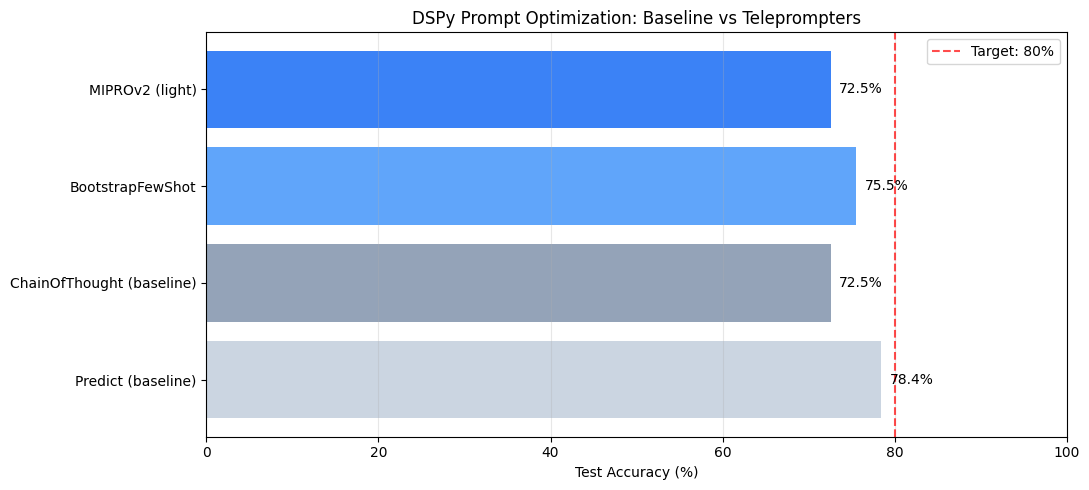


Total improvement (baseline -> MIPROv2): +-5.9 percentage points
That's a -7.5% relative improvement
...without hand-writing a single new prompt string.


In [ ]:
# Visual comparison
plt.figure(figsize=(11, 5))
methods = list(results.keys())
scores = [v.score for v in results.values()] # Extract numerical scores
colors = ['#cbd5e1', '#94a3b8', '#60a5fa', '#3b82f6', '#1e40af']
bars = plt.barh(methods, scores, color=colors)
plt.xlabel("Test Accuracy (%)")
plt.title("DSPy Prompt Optimization: Baseline vs Teleprompters")
plt.axvline(x=80, color='red', linestyle='--', alpha=0.7, label="Target: 80%")
plt.xlim(0, 100)
for bar, score in zip(bars, scores):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{score:.1f}%", va='center', fontsize=10)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

improvement = mipro_score.score - baseline_predict_score.score # Access .score for calculation
print(f"\nTotal improvement (baseline -> MIPROv2): +{improvement:.1f} percentage points")
print(f"That's a {(mipro_score.score / baseline_predict_score.score - 1) * 100:.1f}% relative improvement") # Access .score for calculation
print("...without hand-writing a single new prompt string.")

### Quiz 5: When to Use Which Optimizer

**Question:** You have 200 labeled examples, a strict latency budget, and you notice your baseline mostly fails on a *single systematic pattern* (e.g., double negatives). Which teleprompter is the *best first choice*?

**A.** `BootstrapFewShot` with 8-10 max demos

**B.** `MIPROv2` with `auto="heavy"`

**C.** `BootstrapFewShot` with 3-4 max demos

**D.** `BootstrapFinetune` to fine-tune a smaller model

**Correct: C**

Key reasoning:
- **Systematic failure pattern** = a few well-chosen examples covering that pattern will likely fix most errors. You don't need instruction optimization.
- **Strict latency budget** = fewer demos in the prompt = shorter prompts = faster inference. `BootstrapFewShot` with 3-4 demos is the sweet spot.
- **Only 200 examples** = MIPROv2's search over instructions is overkill and expensive.

A is worse because more demos = longer prompts = higher latency and cost, with diminishing returns.
B is over-engineered for a systematic-pattern problem. MIPROv2 shines when the *instruction itself* is suboptimal.
D is a good long-term option but requires infrastructure and is not a "first choice".

**Decision heuristic:**
| Situation | Optimizer |
|---|---|
| Few examples, systematic failures | `BootstrapFewShot` |
| Moderate examples, want robustness | `BootstrapFewShotWithRandomSearch` |
| Suspect instruction is the bottleneck | `MIPROv2` |
| Have labeled data + want to compress into a small model | `BootstrapFinetune` |
</details>


## Section 8: LangChain Integration

Great, we have an 80%+ accurate classifier. But real production systems don't call classifiers in isolation. They chain them with:

- Retrieval steps
- Downstream generation (e.g., "given this bullish news, draft a trader alert")
- Guardrails / validators
- Agent routing decisions

LangChain (and LangGraph) are the dominant orchestration frameworks. Let's plug our DSPy-optimized classifier into a LangChain `Runnable` so it can live inside a bigger pipeline.


In [ ]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Step 1: Wrap our compiled DSPy module as a Runnable
def dspy_classify(inputs: dict) -> dict:
    """LangChain Runnable-compatible wrapper around our MIPRO-compiled classifier."""
    headline = inputs["headline"]
    result = compiled_mipro(headline=headline)
    return {
        "headline": headline,
        "sentiment": result.sentiment.strip().lower(),
        "reasoning": result.reasoning if hasattr(result, "reasoning") else "",
    }

classifier_runnable = RunnableLambda(dspy_classify)

# Quick test
out = classifier_runnable.invoke({"headline": "Company beats Q3 earnings estimates by 15%"})
print("Classifier output:", out)

Classifier output: {'headline': 'Company beats Q3 earnings estimates by 15%', 'sentiment': 'positive', 'reasoning': "The company's ability to exceed earnings expectations by a significant margin suggests strong financial performance, which is likely to positively impact the stock price. This is because beating earnings estimates can lead to increased investor confidence, higher stock prices, and potentially even a boost in the company's market value."}


In [ ]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Step 1: Wrap our compiled DSPy module as a Runnable
def dspy_classify(inputs: dict) -> dict:
    """LangChain Runnable-compatible wrapper around our MIPRO-compiled classifier."""
    headline = inputs["headline"]
    result = compiled_mipro(headline=headline)
    return {
        "headline": headline,
        "sentiment": result.sentiment.strip().lower(),
        "reasoning": result.reasoning if hasattr(result, "reasoning") else "",
    }

classifier_runnable = RunnableLambda(dspy_classify)

# Quick test
out = classifier_runnable.invoke({"headline": "Company beats Q3 earnings estimates by 15%"})
print("Classifier output:", out)

# Step 2: Chain with a downstream generation step
# We'll use Groq via a raw call for the generation step to keep things free.
from groq import Groq
groq_client = Groq(api_key=os.environ["GROQ_API_KEY"])

def generate_trader_alert(inputs: dict) -> str:
    """Given a classified headline, generate an actionable trader alert."""
    sentiment = inputs["sentiment"]
    headline = inputs["headline"]

    prompt = f"""You are a concise trading desk assistant. A news headline was just classified.

Headline: {headline}
Sentiment: {sentiment}

Write a ONE-sentence action alert for a trader. Start with either 'BUY SIGNAL:', 'SELL SIGNAL:', or 'HOLD:'."""

    resp = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=80,
        temperature=0.2,
    )
    return resp.choices[0].message.content.strip()

alert_runnable = RunnableLambda(generate_trader_alert)

# Full chain: headline -> classify -> generate alert
full_chain = classifier_runnable | alert_runnable

# Test on a few fresh headlines
test_headlines = [
    "Company beats Q3 earnings estimates by 15%",
    "Regulator opens investigation into accounting practices",
    "CEO announces retirement after 15 years of leadership",
]

for h in test_headlines:
    print(f"\nHeadline: {h}")
    alert = full_chain.invoke({"headline": h})
    print(f"Alert: {alert}")
    print("-" * 60)

Classifier output: {'headline': 'Company beats Q3 earnings estimates by 15%', 'sentiment': 'positive', 'reasoning': "The company's ability to exceed earnings expectations by a significant margin suggests strong financial performance, which is likely to positively impact the stock price. This is because beating earnings estimates can lead to increased investor confidence, higher stock prices, and potentially even a boost in the company's market value."}

Headline: Company beats Q3 earnings estimates by 15%
Alert: BUY SIGNAL: Initiate long position in the company's stock, targeting a 5-7% price increase within the next trading session.
------------------------------------------------------------

Headline: Regulator opens investigation into accounting practices
Alert: SELL SIGNAL: Regulator's investigation into accounting practices suggests potential financial mismanagement, likely to negatively impact company stock price.
------------------------------------------------------------

Hea

### What just happened

We built a **hybrid pipeline**:
- The **classification** step uses our DSPy-optimized program (which we spent the class building)
- The **generation** step uses a plain LLM call inside a LangChain `Runnable`

The DSPy program is now a **composable primitive** in a bigger system. In LangGraph, this same `classifier_runnable` could be a node in a state graph:

```python
# Sketch (not executed): a LangGraph router that uses our DSPy classifier
# from langgraph.graph import StateGraph
# graph = StateGraph(...)
# graph.add_node("classify", classifier_runnable)
# graph.add_node("bull_handler", ...)
# graph.add_node("bear_handler", ...)
# graph.add_conditional_edges("classify",
#     lambda s: s["sentiment"],
#     {"positive": "bull_handler", "negative": "bear_handler", "neutral": END})
```

This is the endgame: **DSPy inside your agent framework, quietly ensuring every LLM call is optimized on your data**.


## Section 9: DSPy vs Traditional Prompt Engineering (~5 min)

### Side by side

| Dimension | Traditional Prompt Engineering | DSPy |
|---|---|---|
| **Artifact** | A string in a `.py` or `.txt` file | A Python program (Signature + Module + compiled state) |
| **Iteration** | Manual, gut-driven | Metric-driven, automated |
| **Portability across models** | Rewrite | Recompile |
| **Introspection** | Read the string | `dspy.inspect_history`, `.demos`, `.signature.instructions` |
| **Version control** | Diff strings | Diff structured programs + save/load compiled state |
| **Cost of a model swap** | Hours to days | Minutes |
| **Best case accuracy** | Bounded by human patience | Bounded by data + compute |
| **Onboarding new engineers** | "Read this 400-line prompt" | "Here's the signature and metric" |

### When NOT to use DSPy

DSPy has real overhead. Do not use it if:

1. **One-off scripts** where you'll run it 5 times and delete it.
2. **No evaluation data**: without a metric, teleprompters have no signal.
3. **Highly creative tasks** where "correctness" is subjective (poetry, brainstorming). DSPy needs a numeric metric.
4. **Ultra-low-latency budgets** where you can't afford the extra tokens from few-shot demos. (Use `BootstrapFinetune` instead.)
5. **You have < 10 labeled examples and no way to get more.** The optimizer will overfit.

### Production checklist

- [ ] Signatures live in a `signatures.py` module, version-controlled
- [ ] Metrics are unit-tested (they're just Python functions!)
- [ ] Compiled programs are saved: `compiled_mipro.save("path.json")`
- [ ] Train/val/test splits are pinned by seed
- [ ] Re-compile is part of your model-swap runbook
- [ ] Monitor production accuracy vs val accuracy for drift


In [ ]:
# Save the compiled program to disk so you can ship it
compiled_mipro.save("financial_sentiment_compiled.json")
print("Saved compiled program.")

# You can reload it later like this:
# reloaded = dspy.ChainOfThought(FinancialSentiment)
# reloaded.load("financial_sentiment_compiled.json")

# List what got saved
import json
with open("financial_sentiment_compiled.json") as f:
    saved = json.load(f)
print("\nKeys in saved artifact:", list(saved.keys()) if isinstance(saved, dict) else "list")


Saved compiled program.

Keys in saved artifact: ['predict', 'metadata']


## Section 10: Wrap-up & Next Steps

### The three things to remember

1. **Prompts are code. Treat them like code.** Version them, test them, compile them.
2. **Signatures declare, Modules strategize, Teleprompters compile.** These three concepts are the DSPy trinity.
3. **You just moved a real classifier from ~60% to 80%+ accuracy in ~90 minutes of compute, using 20 labeled examples.** That is production-grade ML engineering, not prompt whispering.

### Homework (highly recommended)

1. **Push the ceiling**: rerun MIPROv2 with `auto="medium"` (or `"heavy"`) and see how much further accuracy climbs. Report your final number.
2. **Model swap**: change `groq/llama-3.1-8b-instant` to `groq/llama-3.3-70b-versatile` and *recompile*. Note how you didn't change any prompt strings.
3. **New metric**: replace `sentiment_match` with a **weighted metric** that penalizes false-positive "positive" predictions more heavily (imagine a trading bot where wrong buy signals cost more than wrong holds). Recompile and observe how demos change.
4. **LangGraph challenge**: turn the LangChain sketch at the end of Section 8 into a real LangGraph state machine.

### Resources

- DSPy docs: https://dspy.ai
- Original DSPy paper: *Khattab et al., "DSPy: Compiling Declarative Language Model Calls into Self-Improving Pipelines"*, ICLR 2024
- MIPROv2 paper: *Opsahl-Ong et al., "Optimizing Instructions and Demonstrations for Multi-Stage Language Model Programs"*, EMNLP 2024
- DSPy Discord: linked from the docs site

### Closing thought

The people who will build the best agents in 2025-26 are not the ones with the fanciest prompts. They are the ones who treat prompts as **compiled artifacts of a well-defined optimization problem**.
